-----------------------------
Demo: Network Embeddings for Biomedical Graphs
-----------------------------

This notebook demonstrates a machine learning approach to discover new, unverified protein-protein interactions (PPIs) within the Homo sapiens (Human) network using Graph Embeddings (Node2Vec) and Link Prediction. Further details on Readme.md

In [ ]:
# -----------------------------
# 0️⃣ Imports
# -----------------------------
import pandas as pd
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.manifold import TSNE, SpectralEmbedding


In [2]:
# -----------------------------
# 1️⃣ Utility Functions
# -----------------------------

def load_string_network(path_links, confidence_threshold=700):
    """Load STRING edges and build NetworkX graph."""
    edges_df = pd.read_csv(path_links, sep=" ", header=0)
    print("Total edges in full network:", len(edges_df))

    edges_df = edges_df[edges_df['combined_score'] > confidence_threshold]
    print("High-confidence edges:", len(edges_df))

    G = nx.from_pandas_edgelist(edges_df, 'protein1', 'protein2')
    print("Total nodes:", G.number_of_nodes())
    print("Total edges:", G.number_of_edges())
    return G


def sample_subgraph(G, n_nodes=2000, seed=42):
    """Sample a subgraph for demo purposes."""
    random.seed(seed)
    sample_nodes = random.sample(list(G.nodes), n_nodes)
    G_demo = G.subgraph(sample_nodes).copy()
    print("Demo graph nodes:", G_demo.number_of_nodes())
    print("Demo graph edges:", G_demo.number_of_edges())
    return G_demo


def generate_node2vec_embeddings(G, dim=64, walk_length=30, num_walks=200, workers=4):
    """Generate Node2Vec embeddings."""
    node2vec = Node2Vec(G, dimensions=dim, walk_length=walk_length, 
                        num_walks=num_walks, workers=workers, seed=42)
    model = node2vec.fit(window=10, min_count=1)
    print("✅ Node2Vec embeddings generated.")
    return model


def generate_baseline_embeddings(G, dim=64):
    """Generate baseline Spectral embeddings."""
    nodes = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes)
    emb = SpectralEmbedding(n_components=dim, random_state=42).fit_transform(A)
    emb_dict = {node: emb[i] for i, node in enumerate(nodes)}
    print("✅ Spectral embeddings generated (baseline).")
    return emb_dict


def get_edge_embedding(model, u, v, method="hadamard"):
    """Compute edge embedding (default: Hadamard product)."""
    if method == "hadamard":
        return model[u] * model[v]
    elif method == "average":
        return (model[u] + model[v]) / 2
    elif method == "l1":
        return np.abs(model[u] - model[v])
    elif method == "l2":
        return (model[u] - model[v]) ** 2


def create_link_dataset(G, model, negative_ratio=1.0):
    """Create positive and negative edge samples with embeddings."""
    edges = list(G.edges())
    all_nodes = list(G.nodes())

    # Negative sampling
    negative_edges = []
    while len(negative_edges) < int(len(edges) * negative_ratio):
        u, v = random.sample(all_nodes, 2)
        if not G.has_edge(u, v):
            negative_edges.append((u, v))

    # Build dataset
    X = np.array([get_edge_embedding(model, u, v) for u, v in edges + negative_edges])
    y = np.array([1]*len(edges) + [0]*len(negative_edges))
    return X, y


def evaluate_classifier(X, y):
    """Train/test split, RandomForest, and ROC/PR evaluation."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                        test_size=0.2, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred)
    print(f"AUC: {auc:.4f}")

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='b')
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Link Prediction')
    plt.legend()
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, color='g')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()

    return clf, y_pred


def visualize_embeddings(model, G, method="tsne"):
    """Visualize embeddings in 2D using t-SNE or spectral reduction."""
    X_emb = np.array([model[n] for n in G.nodes()])
    if method == "tsne":
        reducer = TSNE(n_components=2, random_state=42)
    else:
        reducer = SpectralEmbedding(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(X_emb)

    plt.figure(figsize=(8,6))
    plt.scatter(X_2d[:,0], X_2d[:,1], 
                s=20, 
                c=[G.degree(n) for n in G.nodes()],
                cmap='viridis', alpha=0.7)
    plt.colorbar(label="Node degree")
    plt.title("2D Node2Vec Embeddings - STRING Demo")
    plt.show()

def map_predictions_to_names(predictions_df, protein_info_path="9606.protein.info.v12.0.txt.gz"):
    """Maps protein IDs in a predictions DataFrame to their preferred names."""
    
    # Load the protein info file to create the ID-to-Name map
    try:
        protein_info = pd.read_csv(protein_info_path, sep="\t")
    except FileNotFoundError:
        print(f"Warning: Protein info file not found at {protein_info_path}. Cannot map names.")
        return predictions_df
        
    id2name = dict(zip(protein_info['#string_protein_id'], protein_info['preferred_name']))
    
    # Create new columns with the mapped names
    df_named = predictions_df.copy()
    df_named['name1'] = df_named['protein1'].map(id2name).fillna(df_named['protein1'])
    df_named['name2'] = df_named['protein2'].map(id2name).fillna(df_named['protein2'])
    
    # Reorder columns to show names prominently
    cols = ['protein1', 'name1', 'protein2', 'name2', 'score']
    return df_named[cols]

def visualize_predictions_on_embeddings(model, G, X_2d, perfect_score_predictions):
    """Visualizes node embeddings, highlighting proteins involved in new predictions."""
    
    # Get all nodes involved in the highest-confidence predictions
    predicted_nodes = set(perfect_score_predictions['protein1']).union(
        set(perfect_score_predictions['protein2'])
    )
    
    nodes = list(G.nodes())
    
    # Create a color array: Blue for predicted nodes, Grey for others
    #    (This uses the X_2d array generated by TSNE/Spectral in visualize_embeddings)
    color_map = ['#808080' if n not in predicted_nodes else '#004cff' for n in nodes]
    
    # Create a size array: Larger size for predicted nodes
    size_map = [20 if n not in predicted_nodes else 150 for n in nodes]
    
    plt.figure(figsize=(10, 8))
    
    # Plot all nodes first (smaller, grey)
    plt.scatter(X_2d[:,0], X_2d[:,1], 
                s=size_map, 
                c=color_map, 
                alpha=0.6,
                label='Other Proteins')
    
    # Scatter the predicted nodes again on top (larger, blue)
    predicted_X_2d = np.array([X_2d[i] for i, n in enumerate(nodes) if n in predicted_nodes])
    plt.scatter(predicted_X_2d[:, 0], predicted_X_2d[:, 1],
                s=150, 
                c='#004cff', 
                alpha=0.9, 
                edgecolors='black',
                linewidths=0.5,
                label='Predicted Link Nodes')
    
    plt.title("2D Node2Vec Embeddings - Highlighted Predictions")
    plt.legend()
    plt.show()

Total edges in full network: 13715404
High-confidence edges: 472000
Total nodes: 16185
Total edges: 236000
Demo graph nodes: 2000
Demo graph edges: 3485


Computing transition probabilities: 100%|██████████| 2000/2000 [00:00<00:00, 9504.27it/s]


✅ Node2Vec embeddings generated.
AUC: 0.9986


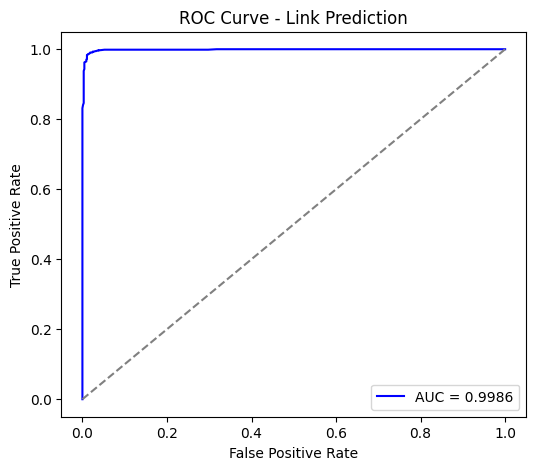

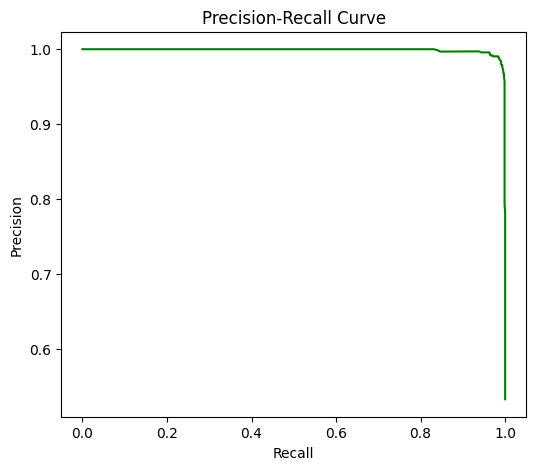

✅ Spectral embeddings generated (baseline).
AUC: 0.9468


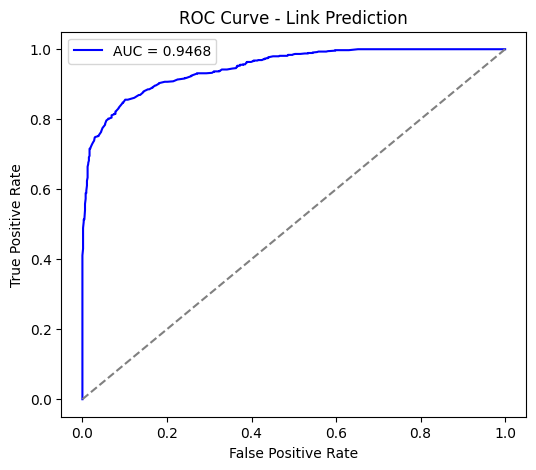

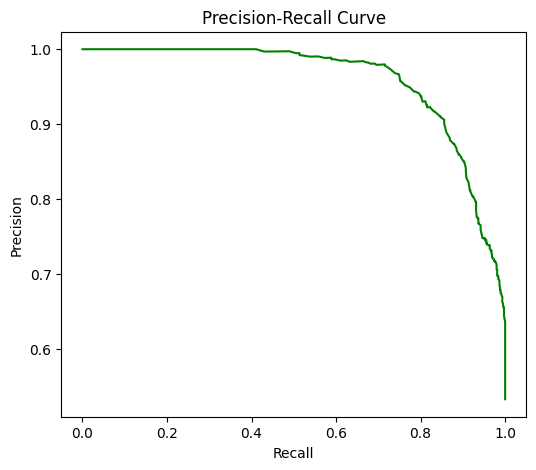


--- New Link Predictions with Perfect Score (1.0) ---
Total count of highly confident new links: 617
            protein1  name1             protein2      name2  score
9606.ENSP00000434034   FZD4 9606.ENSP00000323901       FZD2    1.0
9606.ENSP00000434034   FZD4 9606.ENSP00000286201       FZD7    1.0
9606.ENSP00000434034   FZD4 9606.ENSP00000287934       FZD1    1.0
9606.ENSP00000434034   FZD4 9606.ENSP00000404911   PRICKLE4    1.0
9606.ENSP00000353025  FAM3C 9606.ENSP00000333919       BTLA    1.0
9606.ENSP00000348912 ADAM33 9606.ENSP00000324901       IQCK    1.0
9606.ENSP00000348912 ADAM33 9606.ENSP00000436812      MUC5B    1.0
9606.ENSP00000348912 ADAM33 9606.ENSP00000219837      KNOP1    1.0
9606.ENSP00000348912 ADAM33 9606.ENSP00000324510     BAIAP3    1.0
9606.ENSP00000348912 ADAM33 9606.ENSP00000455026     RPUSD1    1.0
9606.ENSP00000348912 ADAM33 9606.ENSP00000386766   SLC39A10    1.0
9606.ENSP00000348912 ADAM33 9606.ENSP00000488024 SLC22A18AS    1.0
9606.ENSP00000348912 ADAM33

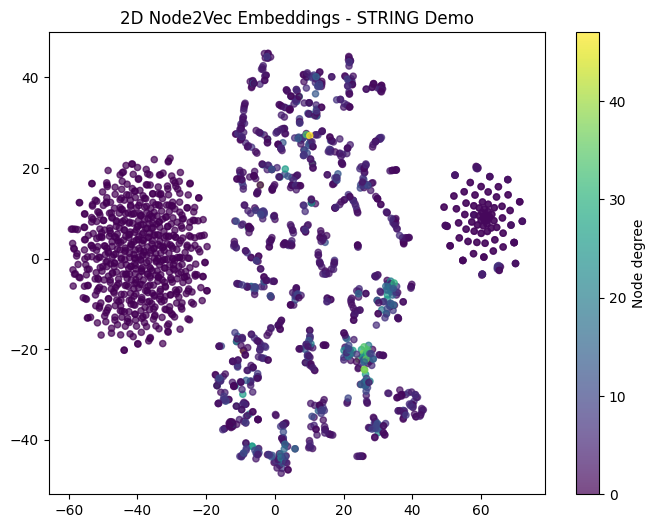

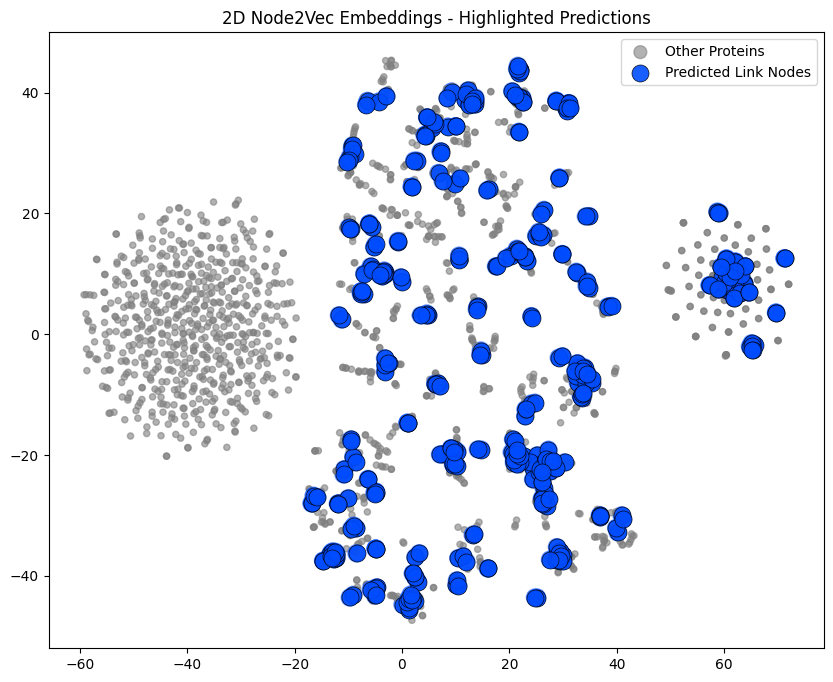

In [3]:

# -----------------------------
# 2️⃣ Main Demo
# -----------------------------

# Load STRING dataset
G = load_string_network("9606.protein.links.v12.0.txt.gz")
G_demo = sample_subgraph(G, n_nodes=2000)

# Node2Vec embeddings
node2vec_model = generate_node2vec_embeddings(G_demo)
X, y = create_link_dataset(G_demo, node2vec_model.wv)
clf, y_pred = evaluate_classifier(X, y)

# Baseline: Spectral Embeddings
spectral_emb = generate_baseline_embeddings(G_demo)
X_spec, y_spec = create_link_dataset(G_demo, spectral_emb)
evaluate_classifier(X_spec, y_spec)

# --- Finding New Links ---
all_nodes = list(G_demo.nodes())
unconnected_pairs = []

# Generate all non-existent pairs
for i in range(len(all_nodes)):
    for j in range(i + 1, len(all_nodes)):
        if not G_demo.has_edge(all_nodes[i], all_nodes[j]):
            unconnected_pairs.append((all_nodes[i], all_nodes[j]))

# Create edge embeddings and predict scores
X_new = np.array([get_edge_embedding(node2vec_model.wv, u, v) for u, v in unconnected_pairs])
y_proba_new = clf.predict_proba(X_new)[:, 1]

predictions_df = pd.DataFrame({'protein1': [p[0] for p in unconnected_pairs],
                               'protein2': [p[1] for p in unconnected_pairs],
                               'score': y_proba_new})

# Filter for perfect scores and map names
perfect_score_predictions = predictions_df[predictions_df['score'] == 1.0].copy()
count = len(perfect_score_predictions)

# Map the IDs to their names
named_predictions = map_predictions_to_names(perfect_score_predictions, "9606.protein.info.v12.0.txt.gz")

print(f"\n--- New Link Predictions with Perfect Score (1.0) ---")
print(f"Total count of highly confident new links: {count}")
# Show only the first 20 named predictions for clean output
print(named_predictions.head(20).to_string(index=False)) 

# --- Visualization of Predictions ---
# Generate 2D coordinates (done outside the visualize function for reuse)
X_emb = np.array([node2vec_model.wv[n] for n in G_demo.nodes()])
reducer = TSNE(n_components=2, random_state=42)
X_2d = reducer.fit_transform(X_emb)


# Visualization Original
visualize_embeddings(node2vec_model.wv, G_demo)

# Run the new visualization function
visualize_predictions_on_embeddings(node2vec_model.wv, G_demo, X_2d, perfect_score_predictions)